# TP1 — Prise en main de Gymnasium  
## Version unique complète : énoncé + explication pédagogique + correction

**Cours : Machine Learning par Renforcement**  
**Niveau : élèves ingénieurs / informatique**  
**Objectif général :** comprendre la boucle fondamentale de l’apprentissage par renforcement à travers l’environnement `CartPole-v1`.


## Intérêt du TP dans le cours RL

Ce TP est la **porte d’entrée** du chapitre Apprentissage par Renforcement. Avant d’aborder **Q-Learning**, **SARSA**, **Deep Q-Network** ou les méthodes avancées, l’étudiant doit comprendre la logique suivante :

> Un agent observe un état, choisit une action, reçoit une récompense, passe à un nouvel état, puis recommence.

Cette boucle est le cœur de tout algorithme RL.


# 1. Rappel pédagogique : la boucle RL

Dans l’apprentissage supervisé, on possède généralement :

- des données d’entrée `X`,
- des sorties attendues `y`,
- un modèle qui apprend à prédire `y`.

Dans l’apprentissage par renforcement, la logique est différente :

- l’agent ne reçoit pas directement la bonne réponse ;
- il agit dans un environnement ;
- il reçoit une récompense positive ou négative ;
- il améliore progressivement sa stratégie.

## Schéma logique

```text
          observation / état
      ┌──────────────────────┐
      │                      ▼
┌───────────┐   action   ┌───────────────┐
│   Agent   │ ─────────▶ │ Environnement │
└───────────┘            └───────────────┘
      ▲                      │
      │                      │ récompense
      └──────────────────────┘ nouvel état
```

Dans ce TP, l’environnement est **CartPole-v1**.

L’objectif est de garder un poteau en équilibre sur un chariot.


# 2. Correspondance entre le cours et CartPole

| Concept RL | Définition générale | Exemple dans CartPole |
|---|---|---|
| Agent | Celui qui prend les décisions | Contrôleur du chariot |
| Environnement | Monde dans lequel l’agent agit | Simulation CartPole |
| État | Information observée | Position, vitesse, angle, vitesse angulaire |
| Action | Décision possible | Aller à gauche ou à droite |
| Récompense | Signal de qualité | +1 à chaque pas si le poteau reste debout |
| Épisode | Suite d’interactions | Jusqu’à la chute du poteau ou limite de temps |
| Politique | Règle de choix des actions | Aléatoire, naïve ou apprise |

Ce TP ne fait pas encore apprendre l’agent. Il montre d’abord **comment communiquer avec un environnement RL**.


# 3. Étape 0 — Installation et importation

Cette étape prépare l’environnement Python.

Dans un  TP , il faut vérifier que les bibliothèques sont installées :

- `gymnasium` : bibliothèque d’environnements RL ;
- `numpy` : calcul scientifique ;
- `matplotlib` : visualisation des résultats.


In [2]:
# À exécuter seulement si les bibliothèques ne sont pas installées :
# !pip install gymnasium matplotlib numpy

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print("Bibliothèques importées avec succès")
print("Version Gymnasium :", gym.__version__)


Bibliothèques importées avec succès
Version Gymnasium : 1.3.0


# 4. Étape 1 — Créer l’environnement CartPole

On crée maintenant l’environnement `CartPole-v1`.

CartPole est un problème classique : un poteau est fixé sur un chariot. L’agent doit déplacer le chariot pour empêcher le poteau de tomber.


In [5]:
env = gym.make("CartPole-v1")

print("Environnement créé :", env.spec.id)
print("Espace des observations :", env.observation_space)
print("Espace des actions :", env.action_space)


Environnement créé : CartPole-v1
Espace des observations : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Espace des actions : Discrete(2)


## Interprétation

`env.observation_space` indique la forme des états observés par l’agent.  
`env.action_space` indique le nombre d’actions possibles.

Dans CartPole :

- action `0` : pousser le chariot vers la gauche ;
- action `1` : pousser le chariot vers la droite.

L’étudiant comprend ici que le RL repose toujours sur deux éléments fondamentaux : **états** et **actions**.


# 5. Étape 2 — Réinitialiser l’environnement

Avant de commencer un épisode, il faut remettre l’environnement à zéro avec `reset()`.


In [6]:
etat_initial, info = env.reset(seed=42)

print("État initial :")
print(etat_initial)
print("Informations complémentaires :", info)


État initial :
[ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Informations complémentaires : {}


## Signification de l’état initial

L’état est un vecteur de 4 valeurs :

| Indice | Signification |
|---|---|
| 0 | Position du chariot |
| 1 | Vitesse du chariot |
| 2 | Angle du poteau |
| 3 | Vitesse angulaire du poteau |

Ces valeurs numériques sont les informations que l’agent utilise pour choisir une action.


# 6. Étape 3 — Exécuter une action

La fonction la plus importante dans Gymnasium est :

```python
env.step(action)
```

Elle applique une action dans l’environnement et retourne le résultat.


In [7]:
# Choisir une action aléatoire
action = env.action_space.sample()
print("Action choisie :", action)

# Appliquer l'action
nouvel_etat, recompense, termine, tronque, info = env.step(action)

print("Nouvel état :", nouvel_etat)
print("Récompense :", recompense)
print("Terminé ?", termine)
print("Tronqué ?", tronque)
print("Info :", info)


Action choisie : 1
Nouvel état : [ 0.02727336  0.18847767  0.03625453 -0.26141977]
Récompense : 1.0
Terminé ? False
Tronqué ? False
Info : {}


## Correction et explication

La ligne :

```python
nouvel_etat, recompense, termine, tronque, info = env.step(action)
```

retourne 5 éléments :

| Élément | Rôle |
|---|---|
| `nouvel_etat` | état obtenu après l’action |
| `recompense` | récompense reçue |
| `termine` | vrai si l’épisode est fini naturellement |
| `tronque` | vrai si l’épisode est arrêté par limite de temps |
| `info` | informations supplémentaires |

C’est exactement la boucle fondamentale RL :

```text
État → Action → Récompense → Nouvel état
```


# 7. Étape 4 — Politique aléatoire

Une politique est une règle qui indique quelle action choisir dans un état donné.

La première politique testée est une **politique aléatoire** : l’agent choisit une action au hasard.


In [8]:
def run_episode_aleatoire(env, seed=None):
    """
    Lance un épisode complet avec une politique aléatoire.
    Retourne la récompense totale obtenue pendant l'épisode.
    """
    etat, info = env.reset(seed=seed)
    termine = False
    tronque = False
    recompense_totale = 0
    nb_pas = 0

    while not (termine or tronque):
        action = env.action_space.sample()
        etat, recompense, termine, tronque, info = env.step(action)
        recompense_totale += recompense
        nb_pas += 1

    return recompense_totale, nb_pas

score, duree = run_episode_aleatoire(env, seed=1)
print("Score obtenu :", score)
print("Durée de l'épisode :", duree, "pas")


Score obtenu : 20.0
Durée de l'épisode : 20 pas


## Interprétation pédagogique

La politique aléatoire est volontairement faible.

Elle sert de **baseline**, c’est-à-dire un point de comparaison minimal.  
Plus tard, lorsqu’on appliquera Q-Learning ou SARSA, on devra montrer que l’agent appris fait mieux que cette stratégie aléatoire.


# 8. Étape 5 — Évaluer la politique sur plusieurs épisodes

Un seul épisode ne suffit pas pour juger une politique.  
On répète donc l’expérience plusieurs fois.


In [9]:
n_episodes = 200
scores_aleatoires = []

env_eval = gym.make("CartPole-v1")

for i in range(n_episodes):
    score, duree = run_episode_aleatoire(env_eval, seed=i)
    scores_aleatoires.append(score)

scores_aleatoires = np.array(scores_aleatoires)

print("Nombre d'épisodes :", n_episodes)
print("Score moyen :", scores_aleatoires.mean())
print("Score minimum :", scores_aleatoires.min())
print("Score maximum :", scores_aleatoires.max())
print("Écart-type :", scores_aleatoires.std())


Nombre d'épisodes : 200
Score moyen : 22.11
Score minimum : 8.0
Score maximum : 93.0
Écart-type : 13.0010730326385


## Pourquoi répéter 200 épisodes ?

En machine learning, un résultat isolé peut être trompeur.  
La performance d’un agent doit être évaluée sur plusieurs épisodes.

On introduit ici des notions importantes :

- moyenne ;
- minimum ;
- maximum ;
- écart-type ;
- stabilité de la politique.


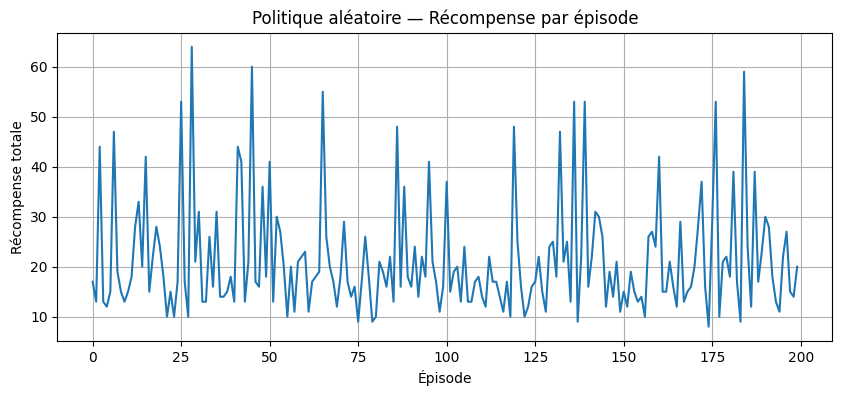

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(scores_aleatoires)
plt.title("Politique aléatoire — Récompense par épisode")
plt.xlabel("Épisode")
plt.ylabel("Récompense totale")
plt.grid(True)
plt.show()


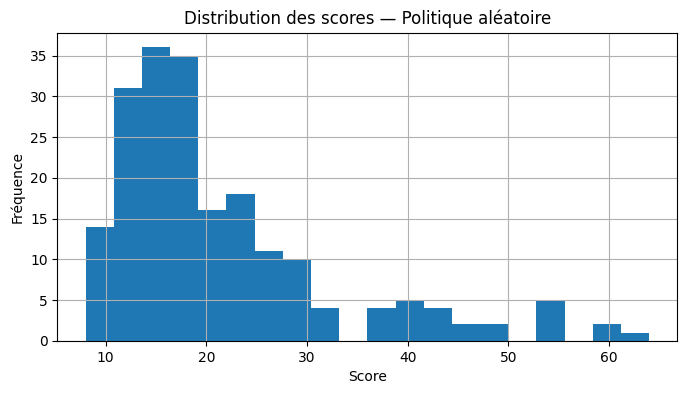

In [37]:
plt.figure(figsize=(8, 4))
plt.hist(scores_aleatoires, bins=20)
plt.title("Distribution des scores — Politique aléatoire")
plt.xlabel("Score")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()


## Analyse des graphiques

Le premier graphique montre l’évolution des scores épisode par épisode.  
Le deuxième graphique montre la distribution des résultats.

Normalement, la politique aléatoire obtient souvent des scores faibles, car elle ne tient pas compte de l’état du poteau.


# 9. Étape 6 — Politique naïve basée sur l’angle

On propose maintenant une politique simple écrite par l’humain.

Idée :

- si le poteau penche vers la droite, pousser à droite ;
- sinon, pousser à gauche.


In [38]:
def politique_naive(etat):
    """
    Politique simple basée uniquement sur l'angle du poteau.
    etat[2] représente l'angle du poteau.
    """
    angle = etat[2]
    if angle > 0:
        return 1  # pousser à droite
    else:
        return 0  # pousser à gauche


def run_episode_politique(env, politique, seed=None):
    """
    Lance un épisode avec une politique donnée.
    """
    etat, info = env.reset(seed=seed)
    termine = False
    tronque = False
    recompense_totale = 0
    nb_pas = 0

    while not (termine or tronque):
        action = politique(etat)
        etat, recompense, termine, tronque, info = env.step(action)
        recompense_totale += recompense
        nb_pas += 1

    return recompense_totale, nb_pas

score, duree = run_episode_politique(env, politique_naive, seed=10)
print("Score politique naïve :", score)
print("Durée :", duree, "pas")


Score politique naïve : 51.0
Durée : 51 pas


## Intérêt pédagogique

Cette politique n’est pas encore apprise automatiquement.  
Elle est écrite manuellement.

Mais elle permet de montrer la différence entre :

| Politique | Principe |
|---|---|
| Aléatoire | choix sans intelligence |
| Naïve | règle humaine simple |
| Apprise | stratégie optimisée par apprentissage |

Cette étape prépare naturellement l’introduction de Q-Learning et SARSA.


# 10. Étape 7 — Comparaison aléatoire vs naïve

On compare maintenant les deux politiques sur le même nombre d’épisodes.


In [39]:
n_episodes = 200
scores_naifs = []

env_eval = gym.make("CartPole-v1")

for i in range(n_episodes):
    score, duree = run_episode_politique(env_eval, politique_naive, seed=i)
    scores_naifs.append(score)

scores_naifs = np.array(scores_naifs)

print("Politique aléatoire — moyenne :", scores_aleatoires.mean())
print("Politique naïve — moyenne :", scores_naifs.mean())
print("Politique naïve — min :", scores_naifs.min())
print("Politique naïve — max :", scores_naifs.max())


Politique aléatoire — moyenne : 21.39
Politique naïve — moyenne : 41.54
Politique naïve — min : 25.0
Politique naïve — max : 59.0


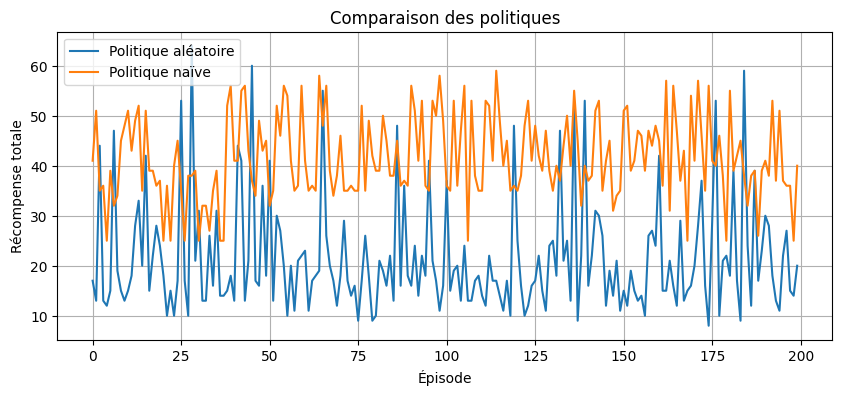

In [40]:
plt.figure(figsize=(10, 4))
plt.plot(scores_aleatoires, label="Politique aléatoire")
plt.plot(scores_naifs, label="Politique naïve")
plt.title("Comparaison des politiques")
plt.xlabel("Épisode")
plt.ylabel("Récompense totale")
plt.legend()
plt.grid(True)
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_14472\134703038.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([scores_aleatoires, scores_naifs], labels=["Aléatoire", "Naïve"])


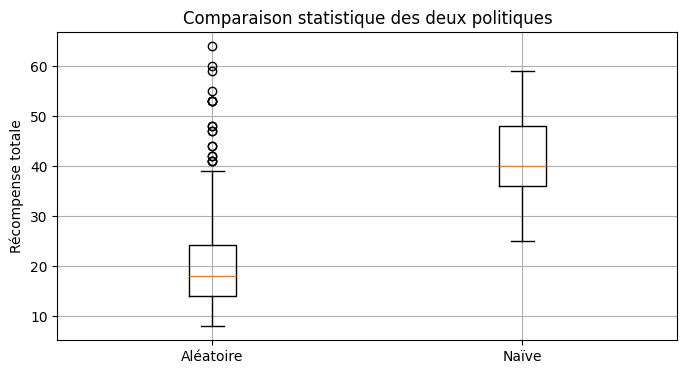

In [41]:
plt.figure(figsize=(8, 4))
plt.boxplot([scores_aleatoires, scores_naifs], labels=["Aléatoire", "Naïve"])
plt.title("Comparaison statistique des deux politiques")
plt.ylabel("Récompense totale")
plt.grid(True)
plt.show()


## Commentaire des résultats

La politique naïve peut être meilleure que la politique aléatoire, car elle utilise une information importante : l’angle du poteau.

Cependant, elle reste limitée parce qu’elle ignore :

- la position du chariot ;
- la vitesse du chariot ;
- la vitesse angulaire du poteau ;
- les conséquences futures des actions.

C’est exactement ce qui justifie l’apprentissage par renforcement : trouver une politique meilleure automatiquement.


# 11. Étape 8 — Lien direct avec Q-Learning et SARSA

Dans les prochains TP, on cherchera à remplacer la règle manuelle par une politique apprise.

## Q-Learning

Q-Learning apprend une fonction :

```text
Q(état, action)
```

Cette fonction estime la qualité d’une action dans un état donné.

## SARSA

SARSA apprend aussi une fonction Q, mais en utilisant l’action réellement choisie par la politique courante.

## Lien avec ce TP

Dans ce TP, on a vu :

```python
action = env.action_space.sample()
```

ou :

```python
action = politique_naive(etat)
```

Dans Q-Learning/SARSA, cette ligne sera remplacée par une décision basée sur la table Q ou un modèle appris.
